# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Fakhrul Ghozali Akbar S
- Email: barz.develop@gmail.com
- Id Dicoding: fakhrul_akbar

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

### Menyiapkan data yang akan diguankan

## Data Understanding

In [33]:
df = pd.read_csv('data/data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**💡 Insight:** Dataset ini memiliki beberapa kelompok kolom sebagai berikut:

- **👤 Data Pribadi & Demografis:**<br>
  Marital_status, Gender, Age_at_enrollment, Nacionality, International  

- **🎓 Data Pendaftaran & Pendidikan:**<br>
  Application_mode, Application_order, Course, Daytime_evening_attendance,<br>
  Previous_qualification, Previous_qualification_grade, Admission_grade  

- **👨‍👩‍👧 Latar Belakang Keluarga:**<br>
  Mothers_qualification, Fathers_qualification, Mothers_occupation, Fathers_occupation  

- **💰 Sosial & Ekonomi Individu:**<br>
  Displaced, Educational_special_needs, Debtor, Tuition_fees_up_to_date, Scholarship_holder  

- **📚 Aktivitas Akademik Semester 1:**<br>
  Curricular_units_1st_sem_credited, Curricular_units_1st_sem_enrolled,<br>
  Curricular_units_1st_sem_evaluations, Curricular_units_1st_sem_approved,<br>
  Curricular_units_1st_sem_grade, Curricular_units_1st_sem_without_evaluations  

- **📚 Aktivitas Akademik Semester 2:**<br>
  Curricular_units_2nd_sem_credited, Curricular_units_2nd_sem_enrolled,<br>
  Curricular_units_2nd_sem_evaluations, Curricular_units_2nd_sem_approved,<br>
  Curricular_units_2nd_sem_grade, Curricular_units_2nd_sem_without_evaluations  

- **🌍 Faktor Ekonomi Makro:**<br>
  Unemployment_rate, Inflation_rate, GDP  

- **🎯 Target:** Status

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

**💡 Insight:** Terdapat 4424 data dengan 35 kolom numerik dan 1 kolom kategorikal sebagai target. 

In [35]:
df.isna().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


**💡 Insight:** tidak ada missing value pada data

In [36]:
duplicated = df.duplicated().sum()
print(f'duplicated data : {duplicated}')

duplicated data : 0


**💡 Insight:** tidak ada duplikat data 

In [37]:
df.describe(include='all')

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [38]:
df.describe(include='object')

,Status
count,4424
unique,3
top,Graduate
freq,2209


In [39]:
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

**💡 Insight:** Secara umum, dataset dalam kondisi baik dan sudah didominasi data numerik, bersih, dan tidak menunjukkan anomali besar, sehingga siap digunakan untuk analisis lanjutan maupun modeling.

Mayoritas data target / status terdapat pada nilai "Graduate"

In [41]:
# 🔹 Marital Status
marital_status_map = {
    1: "Single",
    2: "Married",
    3: "Widower",
    4: "Divorced",
    5: "Facto Union",
    6: "Legally Separated"
}

# 🔹 Application Mode
application_mode_map = {
    1: "1st phase - general contingent",
    2: "Ordinance No. 612/93",
    5: "1st phase - special contingent (Azores)",
    7: "Holders of other higher courses",
    10: "Ordinance No. 854-B/99",
    15: "International student",
    16: "Special contingent (Madeira)",
    17: "2nd phase - general contingent",
    18: "3rd phase - general contingent",
    26: "Different Plan",
    27: "Other Institution",
    39: "Over 23 years old",
    42: "Transfer",
    43: "Change of course",
    44: "Technological specialization diploma",
    51: "Change of institution/course",
    53: "Short cycle diploma",
    57: "International change"
}

# 🔹 Course
course_map = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (evening)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equinculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (evening)"
}

# 🔹 Daytime / Evening
attendance_map = {
    1: "Daytime",
    0: "Evening"
}

# 🔹 Previous Qualification
previous_qualification_map = {
    1: "Secondary education",
    2: "Bachelor degree",
    3: "Degree",
    4: "Master",
    5: "Doctorate",
    6: "Frequency of higher education",
    9: "12th year not completed",
    10: "11th year not completed",
    12: "Other - 11th year",
    14: "10th year",
    15: "10th year not completed",
    19: "Basic education 3rd cycle",
    38: "Basic education 2nd cycle",
    39: "Technological specialization",
    40: "Higher education degree (1st cycle)",
    42: "Professional higher technical",
    43: "Master (2nd cycle)"
}

# 🔹 Nationality
nationality_map = {
    1: "Portuguese",
    2: "German",
    6: "Spanish",
    11: "Italian",
    13: "Dutch",
    14: "English",
    17: "Lithuanian",
    21: "Angolan",
    22: "Cape Verdean",
    24: "Guinean",
    25: "Mozambican",
    26: "Santomean",
    32: "Turkish",
    41: "Brazilian",
    62: "Romanian",
    100: "Moldova",
    101: "Mexican",
    103: "Ukrainian",
    105: "Russian",
    108: "Cuban",
    109: "Colombian"
}

# 🔹 Binary Features (umum)
binary_map = {
    1: "Yes",
    0: "No"
}

# 🔹 Gender
gender_map = {
    1: "Male",
    0: "Female"
}

# 🔹 Target
target_map = {
    "Dropout": 0,
    "Enrolled": 1,
    "Graduate": 2
}

# atau kebalik (buat output)
target_label_map = {
    0: "Dropout",
    1: "Enrolled",
    2: "Graduate"
}

In [60]:
def apply_mapping(df):
    df_mapped = df.copy()

    if 'Marital_status' in df.columns:
        df_mapped['Marital_status'] = df['Marital_status'].map(marital_status_map)

    if 'Application_mode' in df.columns:
        df_mapped['Application_mode'] = df['Application_mode'].map(application_mode_map)

    if 'Course' in df.columns:
        df_mapped['Course'] = df['Course'].map(course_map)

    if 'Daytime_evening_attendance' in df.columns:
        df_mapped['Daytime_evening_attendance'] = df['Daytime_evening_attendance'].map(attendance_map)

    if 'Previous_qualification' in df.columns:
        df_mapped['Previous_qualification'] = df['Previous_qualification'].map(previous_qualification_map)

    if 'Nationality' in df.columns:
        df_mapped['Nationality'] = df['Nationality'].map(nationality_map)

    if 'Gender' in df.columns:
        df_mapped['Gender'] = df['Gender'].map(gender_map)

    binary_cols = ['Tuition_fees_up_to_date', 'Scholarship_holder', 'Debtor', 'International', 'Displaced', 'Educational_special_needs']
    for col in binary_cols:
        if col in df.columns:
            df_mapped[col] = df[col].map(binary_map)


    return df_mapped

df_mapping = apply_mapping(df)

df_mapping.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Status_encoded
0,Single,2nd phase - general contingent,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
1,Single,International student,1,Tourism,Daytime,Secondary education,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,2
2,Single,1st phase - general contingent,5,Communication Design,Daytime,Secondary education,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
3,Single,2nd phase - general contingent,2,Journalism and Communication,Daytime,Secondary education,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,2
4,Married,Over 23 years old,1,Social Service (evening),Evening,Secondary education,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,2


In [68]:
df_mapping.to_csv("data/data_mapping.csv", index=False)
print("Data mapping telah disimpan ke data_mapping.csv")

Data mapping telah disimpan ke data_mapping.csv


**💡 Insight:** Melakukan mapping agar lebih mudah dieksplor

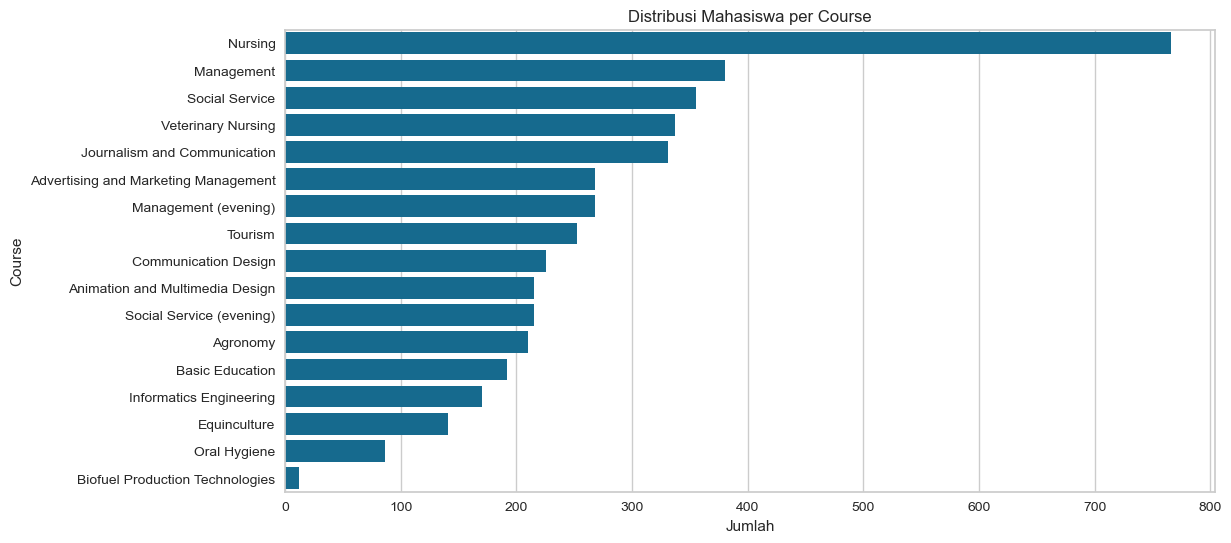

In [62]:
plt.figure(figsize=(12,6))
sns.countplot(
    y=df_mapping['Course'],
    order=df_mapping['Course'].value_counts().index
)

plt.title("Distribusi Mahasiswa per Course")
plt.xlabel("Jumlah")
plt.ylabel("Course")
plt.show()

**💡 Insight:** jumlah mahasiswa didominasi mengambil kelas kepertawatan (nursing), lalu manajemen (management), dan sosial(social service)

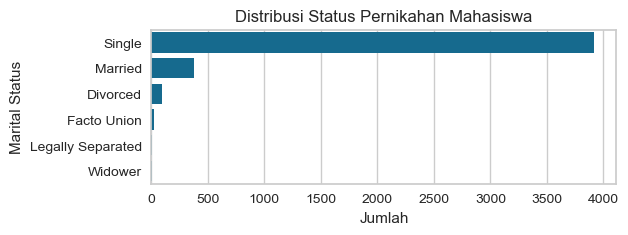

In [63]:
plt.figure(figsize=(6,2))
sns.countplot(
    y=df_mapping['Marital_status'],
    order=df_mapping['Marital_status'].value_counts().index
)

plt.title("Distribusi Status Pernikahan Mahasiswa")
plt.xlabel("Jumlah")
plt.ylabel("Marital Status")
plt.show()

**💡 Insight:** mahasiswa didominasi status lajang (single)

In [65]:
attendance_counts = df_mapping['Daytime_evening_attendance'].value_counts()
gender_counts = df_mapping['Gender'].value_counts()
deptor_counts = df_mapping['Debtor'].value_counts()
tuition_counts = df_mapping['Tuition_fees_up_to_date'].value_counts()


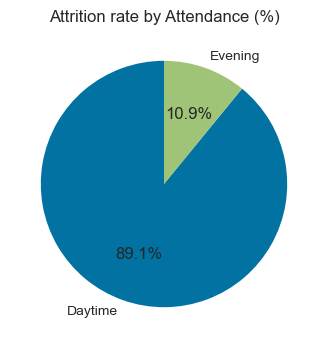

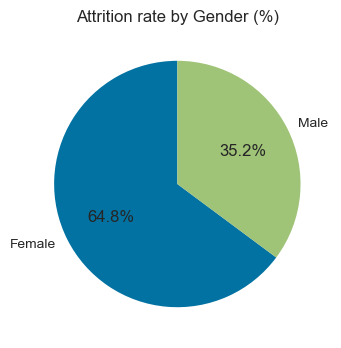

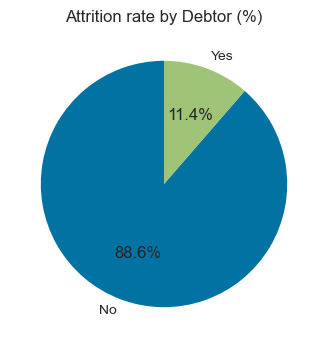

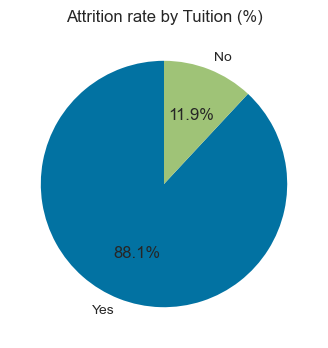

In [66]:
def pie (data, title):
  plt.figure(figsize=(4,4))
  plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
  plt.title(f'Attrition rate by {title} (%)', fontsize=12)
  plt.show()


pie(attendance_counts, 'Attendance')
pie(gender_counts, 'Gender')
pie(deptor_counts, 'Debtor')
pie(tuition_counts, 'Tuition')


**💡 Insight** Distribusi Data Mahasiswa

- **Waktu Kuliah**: Siang **89.1%**, Malam **10.9%**  
- **Gender**: Perempuan **64.8%**, Laki-laki **35.2%**  
- **Status Tunggakan (Debtor)**: Tidak **88.6%**, Ya **11.4%**  
- **Status Pembayaran**: Lancar **88.1%**, Tidak Lancar **11.9%**

## Data Preparation / Preprocessing

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])

dict(zip(le.classes_, le.transform(le.classes_)))

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

**💡 Insight:** memberikan encoding pada kolom status, dengan nilai Dropout = 0, Enrolled = 1, Graduate = 2

Text(0.5, 1.0, 'Correlation Matrix')

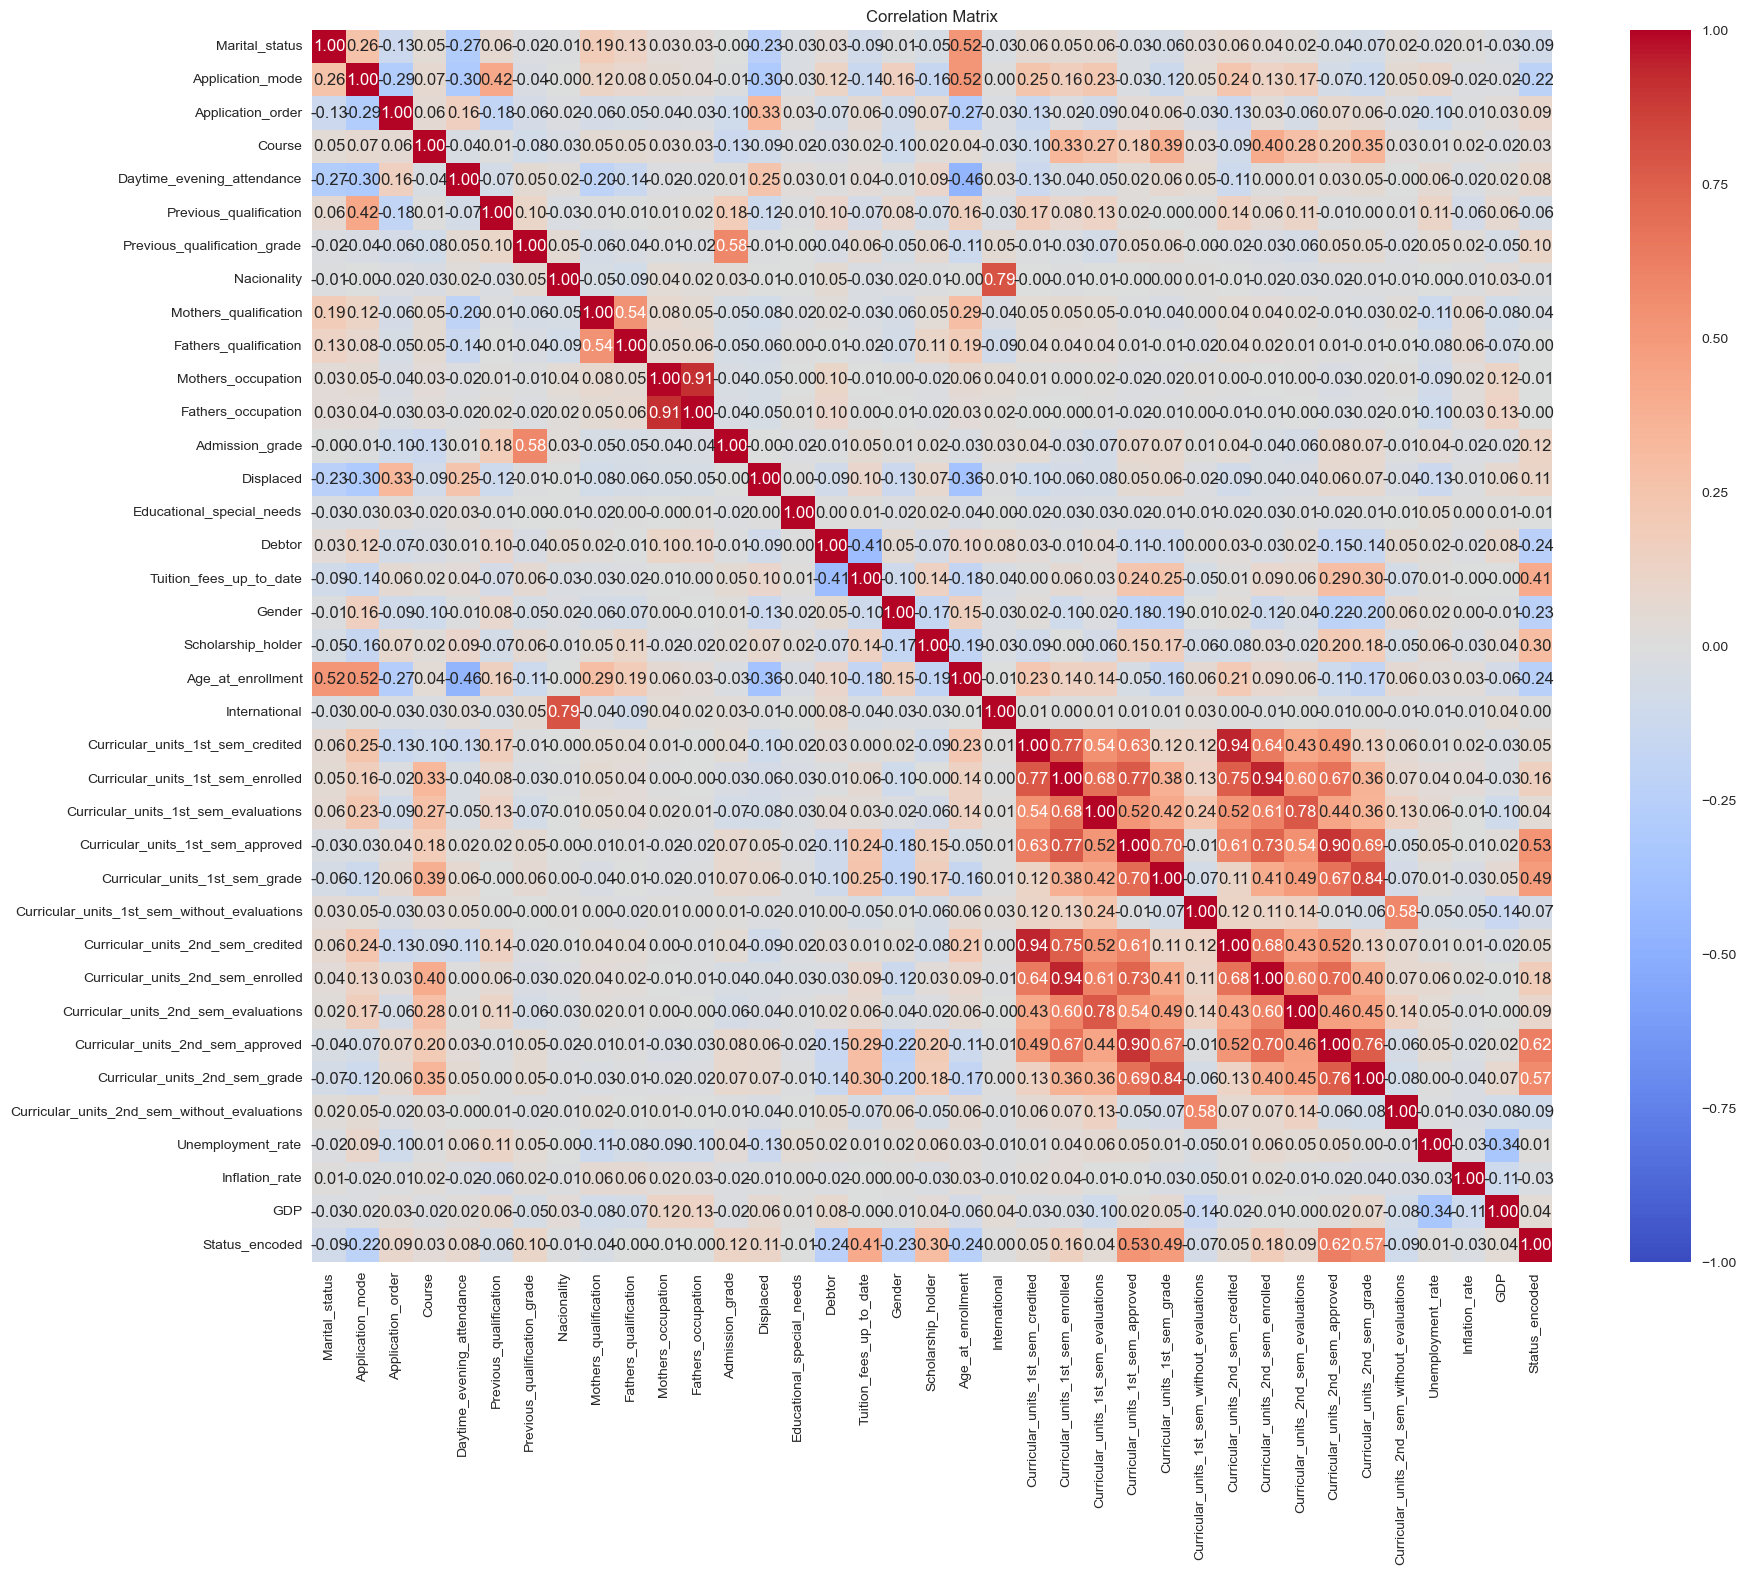

In [47]:
plt.figure(figsize=(20, 16)) 
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix')

In [48]:
corr = df.corr(numeric_only=True)

corr_target = corr['Status_encoded'].sort_values(ascending=False)

corr_target

Status_encoded                                  1.000000
Curricular_units_2nd_sem_approved               0.624157
Curricular_units_2nd_sem_grade                  0.566827
Curricular_units_1st_sem_approved               0.529123
Curricular_units_1st_sem_grade                  0.485207
Tuition_fees_up_to_date                         0.409827
Scholarship_holder                              0.297595
Curricular_units_2nd_sem_enrolled               0.175847
Curricular_units_1st_sem_enrolled               0.155974
Admission_grade                                 0.120889
Displaced                                       0.113986
Previous_qualification_grade                    0.103764
Curricular_units_2nd_sem_evaluations            0.092721
Application_order                               0.089791
Daytime_evening_attendance                      0.075107
Curricular_units_2nd_sem_credited               0.054004
Curricular_units_1st_sem_credited               0.048150
Curricular_units_1st_sem_evalua

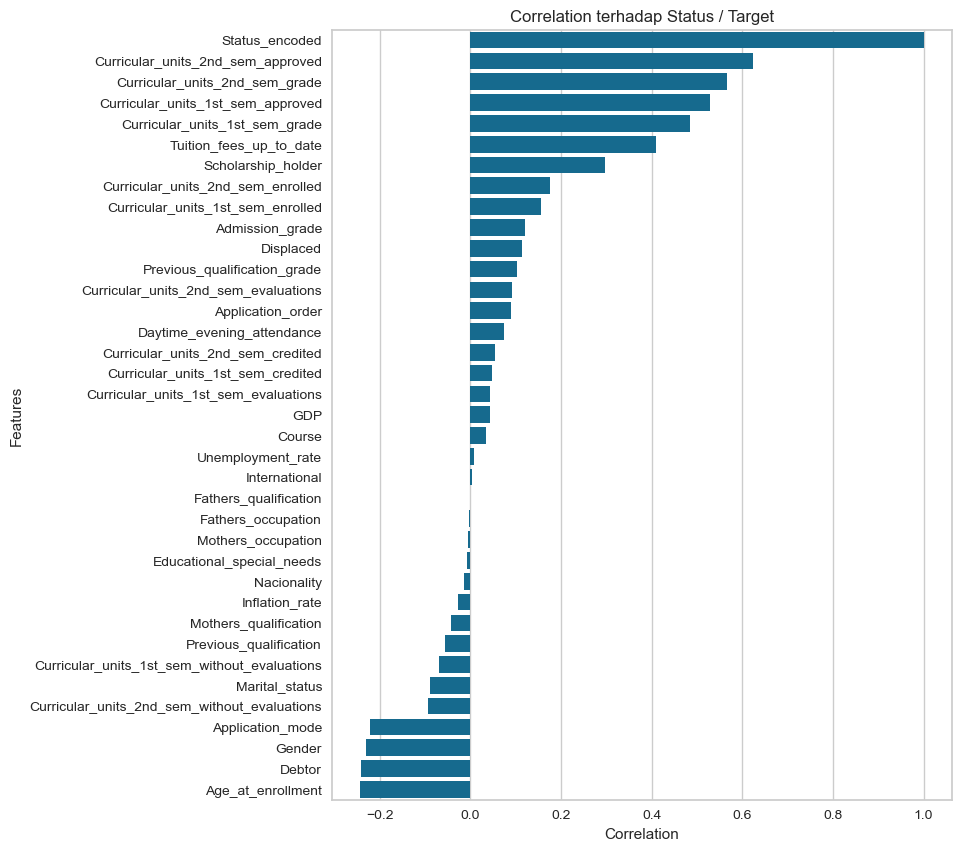

In [49]:
import seaborn as sns

plt.figure(figsize=(8,10))
sns.barplot(x=corr_target.values, y=corr_target.index)

plt.title('Correlation terhadap Status / Target')
plt.xlabel('Correlation')
plt.ylabel('Features')

plt.show()

**💡 Insight:**

Berdasarkan analisis korelasi terhadap **Status_encoded**, faktor yang paling berpengaruh adalah performa akademik mahasiswa, terutama **Curricular_units_2nd_sem_approved**, **Curricular_units_2nd_sem_grade**, **Curricular_units_1st_sem_approved**, dan **Curricular_units_1st_sem_grade** yang menunjukkan korelasi positif cukup kuat. Selain itu, faktor finansial seperti **Tuition_fees_up_to_date** dan **Scholarship_holder** juga berkontribusi terhadap status yang lebih baik.

Di sisi lain, beberapa faktor seperti **Age_at_enrollment**, **Debtor**, **Gender**, dan **Application_mode** memiliki korelasi negatif yang mengindikasikan potensi risiko terhadap status mahasiswa. Sementara itu, variabel lain seperti kondisi ekonomi makro dan latar belakang orang tua cenderung memiliki pengaruh yang sangat kecil.

**Kesimpulan:** Keberhasilan status mahasiswa lebih banyak ditentukan oleh kinerja akademik dan kondisi finansial dibandingkan faktor demografis atau eksternal.

In [50]:
features = [
    # Akademik 
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',

    # Finansial
    'Tuition_fees_up_to_date',
    'Scholarship_holder',
    'Debtor',

    # Demografi
    'Age_at_enrollment',
    'Gender',

    # Aktivitas
    'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_1st_sem_enrolled',

    # Background
    'Admission_grade',
    'Previous_qualification_grade',
    'Application_mode',
    'Daytime_evening_attendance'
]

**💡 Insight:** memilih fitur yg dirasa representatif seperti segi akademik, finansial, demografi, aktivitas maupun segi latar belakang / background

In [51]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['Status_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3539, 15)
X_test : (885, 15)
y_train: (3539,)
y_test : (885,)


**💡 Insight:** membagi data latih dan data uji

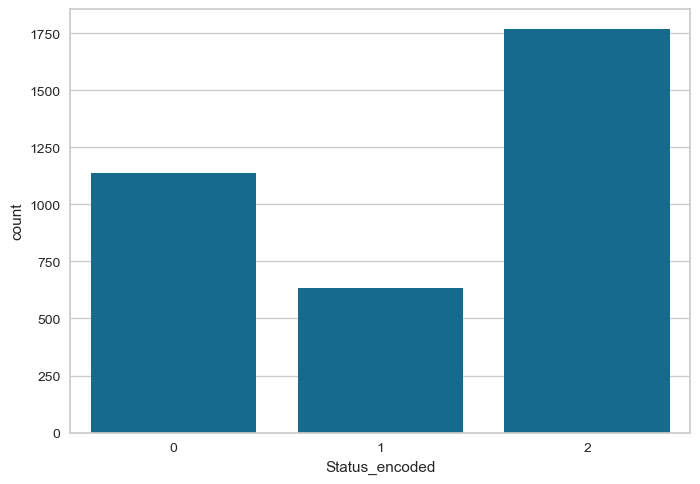

In [52]:
sns.countplot(x=y_train)
plt.show()

**💡 Insight:** data train tidak menunjukkan overpopulasi signifikan

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**💡 Insight:** perlu dilakukan scaling karena beberapa fitur memiliki rentang nilai yang jauh lebih besar dibandingkan yang lain, sehingga mencegah dominasi fitur tertentu saat pelatihan model.

## Modeling

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  
)

rf.fit(X_train_scaled, y_train)

print("Model berhasil dibuat")

Model berhasil dibuat


In [ ]:
joblib.dump(rf, "model/rf_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
print("Model berhasil diekspor")

Model berhasil diekspor


**💡 Insight:** melakukan modeling dan melakukan export model

## Evaluation

In [ ]:
y_pred = rf.predict(X_test_scaled)

print( "Accuracy:", accuracy_score(y_test, y_pred), "\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7649717514124293 

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.76      0.77       284
           1       0.51      0.31      0.39       159
           2       0.80      0.93      0.86       442

    accuracy                           0.76       885
   macro avg       0.70      0.67      0.67       885
weighted avg       0.74      0.76      0.75       885


Confusion Matrix:

[[215  29  40]
 [ 46  50  63]
 [ 10  20 412]]


**💡 Insight Model Random Forest**

Model Random Forest menunjukkan performa cukup baik dengan **accuracy 0.76**, artinya sebagian besar data berhasil diklasifikasikan dengan benar. Namun, terdapat **perbedaan performa antar kelas**.

- **Kelas 2 (Graduate)**: performa sangat baik dengan **recall 0.93** dan **f1-score 0.86**, hampir seluruh data kelas ini dikenali dengan tepat (412 dari 442 data).  
- **Kelas 0 (Dropout)**: performa cukup stabil dengan **f1-score 0.77**, meski masih ada beberapa kesalahan prediksi ke kelas lain.  
- **Kelas 1 (Enrolled)**: performa lemah dengan **recall 0.31** dan **f1-score 0.39**, banyak data salah diklasifikasikan ke kelas 0 atau 2, menunjukkan kesulitan model membedakan kelas minoritas.

Berdasarkan confusion matrix untuk kelas 1:
- **46 data salah ke kelas 0**  
- **63 data salah ke kelas 2**

Hal ini menunjukkan bahwa **kelas 1 memiliki karakteristik mirip dengan kelas 0 dan 2**, sehingga model kesulitan membedakannya.

---

**📌 Kesimpulan**

Secara keseluruhan, model memiliki performa cukup baik, tetapi masih menunjukkan **bias terhadap kelas dominan (Graduate / kelas 2)**.  
Model belum mampu mengenali dengan baik **kelas minor (Enrolled / kelas 1)**, yang terlihat dari rendahnya recall.